# **Coupled 2-species reaction–diffusion** vs simulation (d = 1)

The first multi-species demo of the coupled-field machinery (Dyson 3a–3c + dressing):

- **Matrix reaction coupling** $M = \begin{pmatrix} \mu_a & g \\ -h & \mu_b \end{pmatrix}$ with $gh > (\mu_a-\mu_b)^2/4$ ⇒ a **complex eigenvalue pair** — damped-oscillatory modes, so the cross-correlator $C_{ab}(\tau)$ is genuinely **asymmetric in τ**.
- **Cross-correlations** $C_{ab}(x,\tau)$ alongside $C_{aa}$, both to **1-loop** (cubic vertices) via the spectral-assignment driver — every coupled diagram is a weighted sum of scalar chamber integrals.
- **Unequal diffusion** ($D_a \neq D_b$): the Dyson–Duhamel dressed tree correlator, with the truncation-order **ladder** converging to the exact matrix-heat-kernel oracle.

Validated machinery: `tests/test_coupled_{two_point,tree_e2e,loop,rd_sim}.py`, `tests/test_dyson_dressing.py`; plan: `docs/dyson_duhamel_integration_plan.md`.

In [1]:
import os, sys, time
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(os.path.join(_root, 'notebooks'))
import numpy as np
import matplotlib.pyplot as plt
from pipeline.compute import compute_cumulants
from pipeline.theory import SpatialTheoryBuilder
from models.coupled_rd_1d_sim import simulate_coupled_rd_1d, coupled_box_correlator

# ---- physics ----------------------------------------------------------------
mua, mub = 1.5, 1.2          # decay rates
g, h     = 0.4, 0.3          # cross-reaction:  a <- +g*b,   b <- -h*a
D0       = 0.8               # equal diffusion (sections 1-3)
ga, gb   = 0.3, 0.3          # stabilizing cubic nonlinearities
Ta, Tb   = 1.0, 0.7          # white-noise amplitudes (action -T*phit^2)

Mmat   = np.array([[mua, g], [-h, mub]])
Nnoise = np.diag([2*Ta, 2*Tb])           # <xi xi^T> = 2T (action convention)
eig    = np.linalg.eigvals(Mmat)
print('reaction matrix eigenvalues:', np.round(eig, 4), ' (complex pair -> damped oscillation)')

def coupled_rd(Da, Db, ga_=ga, gb_=gb, dyson=None, periodic_L=None):
    b = (SpatialTheoryBuilder('coupled-rd-2species-1d')
         .physical_field('a', spatial_dim=1)
         .physical_field('b', spatial_dim=1)
         .parameter('mua', default=mua, domain='positive')
         .parameter('mub', default=mub, domain='positive')
         .parameter('Da', default=Da, domain='positive')
         .parameter('Db', default=Db, domain='positive')
         .parameter('g',  default=g)
         .parameter('h',  default=h)
         .parameter('ga', default=ga_)
         .parameter('gb', default=gb_)
         .parameter('Ta', default=Ta, domain='positive')
         .parameter('Tb', default=Tb, domain='positive'))
    act = ('at*((Dt+mua-Da*Laplacian)*a + g*b + ga*a^3) '
           '+ bt*((Dt+mub-Db*Laplacian)*b - h*a + gb*b^3) '
           '- Ta*at^2 - Tb*bt^2')
    b = (b.set_action_text(act)
          .equation(lhs='(Dt+mua-Da*Laplacian)*a + g*b + ga*a^3', rhs='0')
          .equation(lhs='(Dt+mub-Db*Laplacian)*b - h*a + gb*b^3', rhs='0'))
    b = (b.boundary('periodic', length=float(periodic_L)) if periodic_L
         else b.boundary('infinite'))
    if dyson is not None:
        b = b.dyson_order(dyson)
    return b.initial('stationary').build()

def fund(Da, Db, ga_=ga, gb_=gb):
    return {'mua': mua, 'mub': mub, 'Da': Da, 'Db': Db, 'g': g, 'h': h,
            'ga': ga_, 'gb': gb_, 'Ta': Ta, 'Tb': Tb}

reaction matrix eigenvalues: [1.35+0.3122j 1.35-0.3122j]  (complex pair -> damped oscillation)


## 0. The model

$$\partial_t a = -\mu_a a - g\,b - g_a a^3 + D_a \partial_x^2 a + \eta_a, \qquad
  \partial_t b = -\mu_b b + h\,a - g_b b^3 + D_b \partial_x^2 b + \eta_b,$$
with $\langle \eta_i(x,t)\eta_j(x',t')\rangle = 2T_i\,\delta_{ij}\,\delta(x-x')\delta(t-t')$.  The $(+g, -h)$ coupling makes the reaction matrix non-normal with a complex mode pair $m_\pm \approx 1.35 \pm 0.33i$: $b$ excites $a$, $a$ suppresses $b$ — a damped predator–prey loop at every wavenumber.  Sections 1–3 use **equal diffusion** $D_a = D_b = D_0$ (loops supported); section 4 dresses **unequal diffusion** at tree level.

In [2]:
# ============================  CHOOSE THE ORDER  ============================
MAX_ELL  = 1        # 0 = tree, 1 = +1-loop (coupled loops via spectral assignments)
VERBOSE  = False
# ===========================================================================
xs   = np.linspace(0.0, 5.0, 21)         # output separations x >= 0
kw = dict(k=2, spatial_grid=xs, tau_max=0.8, tau_step=0.4,   # tau grid: -0.8..0.8
          max_ell=MAX_ELL, verbose=VERBOSE, use_cache=False, parallel=False,
          mf_dae_n_starts=4)
LEGS = {'aa': [('a', 1), ('a', 1)], 'ab': [('a', 1), ('b', 1)]}
print('computing C_aa and C_ab at orders 0..%d, tau grid -0.8..0.8' % MAX_ELL)

computing C_aa and C_ab at orders 0..1, tau grid -0.8..0.8


## 1. Theory through `compute_cumulants` (equal D, infinite domain)

One call per leg pair; `C_by_order` returns every cumulative order from the same run.  The tree is the **analytic spectral IFT** of the matrix Lyapunov correlator $C(q,\tau) = e^{-A(q)|\tau|}\Sigma(q)$; each loop diagram is evaluated as $\mathrm{pv}\cdot\sum_{\{\alpha\}} \prod_r [P_{\alpha_r}]\, I_{\rm scalar}(\{m_\alpha\})$ over per-segment spectral assignments.

In [3]:
th = {}                                   # th[pair][ell] -> (n_tau, n_x) array
taus_th = None
for pair, legs in LEGS.items():
    t0 = time.time()
    out = compute_cumulants(coupled_rd(D0, D0), fundamental=fund(D0, D0),
                            external_fields=legs, **kw)
    si = out.get('spatial_info', {}) or {}
    taus_th = np.asarray(out['tau_grid'])
    th[pair] = {ell: np.asarray(C) for ell, C in si['C_by_order'].items()}
    i0 = int(np.argmin(np.abs(taus_th)))
    print('C_%s: tree C(0,0) = %.4f   tree+1-loop = %.4f   live diagrams = %s   (%.0fs)'
          % (pair, th[pair][0][i0, 0], th[pair][MAX_ELL][i0, 0],
             si.get('n_live_diagrams', '-'), time.time() - t0))
i0 = int(np.argmin(np.abs(taus_th)))

C_aa: tree C(0,0) = 0.4570   tree+1-loop = 0.3941   live diagrams = 8   (5s)


C_ab: tree C(0,0) = -0.0024   tree+1-loop = -0.0016   live diagrams = 16   (4s)


## 2. Simulation of the coupled SPDE

Semi-implicit Crank–Nicolson Euler–Maruyama on a periodic box ($L = 20 \gg$ correlation length, so boundary effects are negligible against the infinite-domain theory), with the FFT cross-correlation estimator and replica error bars.

In [4]:
t0 = time.time()
sim = simulate_coupled_rd_1d(Mmat, D0, Nnoise, g=(ga, gb), L=20.0, n_x=128,
                             dt=2e-3, t_burn=30.0, t_run=400.0, n_rep=4,
                             seed=2, lags=(0.0, 0.4, 0.8))
x_sim   = sim['x_grid']
half    = len(x_sim) // 2 + 1
xs_sim  = x_sim[:half]
C_sim   = sim['C'][:, :, :, :half]        # (n_tau, 2, 2, n_x/2)
E_sim   = sim['C_err'][:, :, :, :half]
print('sim done (%.0fs): C_aa(0,0) = %.4f +- %.4f,  C_ab(0,0) = %.4f +- %.4f'
      % (time.time() - t0, C_sim[0, 0, 0, 0], E_sim[0, 0, 0, 0],
         C_sim[0, 0, 1, 0], E_sim[0, 0, 1, 0]))

sim done (17s): C_aa(0,0) = 0.4093 +- 0.0011,  C_ab(0,0) = -0.0017 +- 0.0012


## 3. Compare: tree vs tree + 1-loop vs simulation

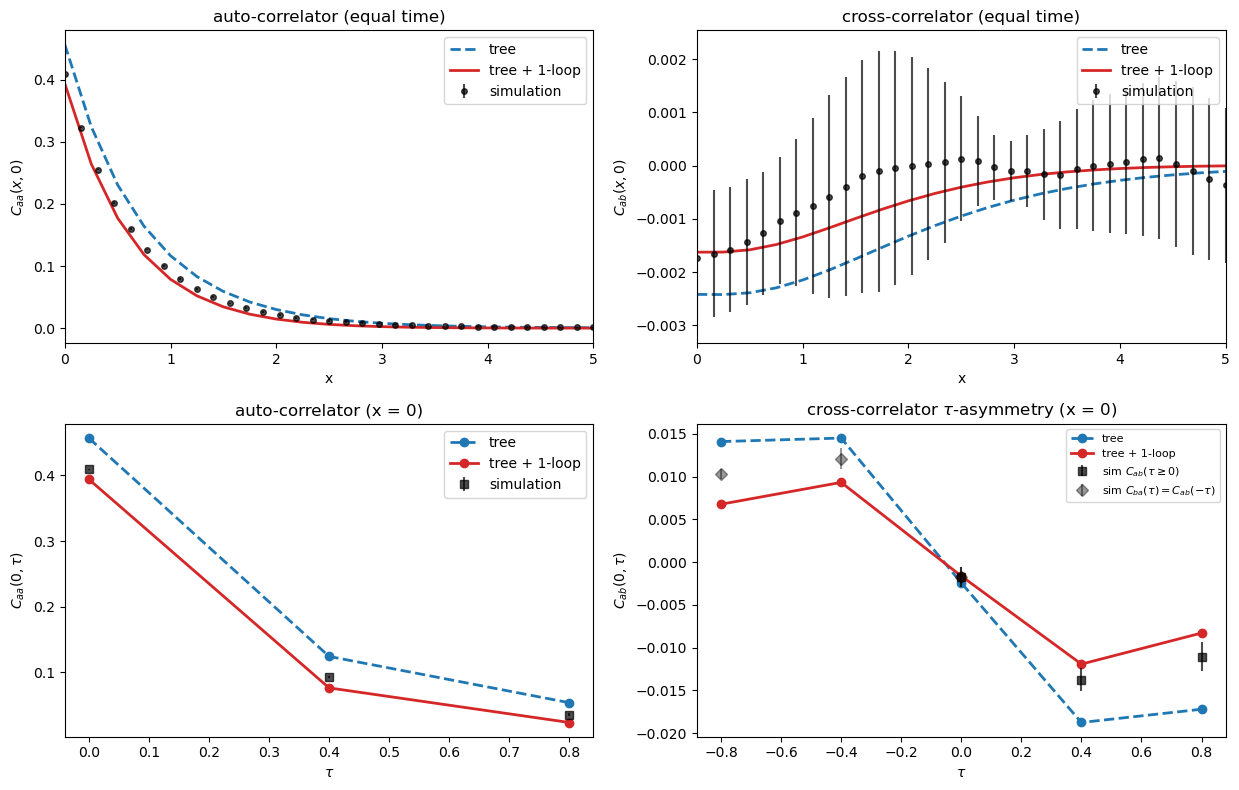

distance |sim - theory| at (x, tau) = (0, 0):
   C_aa  tree           |delta| = 0.0477   (sim 0.4093 +- 0.0011)
   C_aa  tree + 1-loop  |delta| = 0.0153   (sim 0.4093 +- 0.0011)
   C_ab  tree           |delta| = 0.0007   (sim -0.0017 +- 0.0012)
   C_ab  tree + 1-loop  |delta| = 0.0001   (sim -0.0017 +- 0.0012)


In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12.5, 8))

# (a) C_aa(x, 0)
a = ax[0, 0]
a.plot(xs, th['aa'][0][i0], '--', lw=2, color='C0', label='tree')
a.plot(xs, th['aa'][MAX_ELL][i0], '-', lw=2, color='C3', label='tree + 1-loop')
a.errorbar(xs_sim, C_sim[0, 0, 0], yerr=E_sim[0, 0, 0], fmt='o', ms=4,
           color='k', alpha=0.7, label='simulation')
a.set_xlim(0, xs.max()); a.set_xlabel('x'); a.set_ylabel(r'$C_{aa}(x, 0)$')
a.set_title('auto-correlator (equal time)'); a.legend()

# (b) C_ab(x, 0)
a = ax[0, 1]
a.plot(xs, th['ab'][0][i0], '--', lw=2, color='C0', label='tree')
a.plot(xs, th['ab'][MAX_ELL][i0], '-', lw=2, color='C3', label='tree + 1-loop')
a.errorbar(xs_sim, C_sim[0, 0, 1], yerr=E_sim[0, 0, 1], fmt='o', ms=4,
           color='k', alpha=0.7, label='simulation')
a.set_xlim(0, xs.max()); a.set_xlabel('x'); a.set_ylabel(r'$C_{ab}(x, 0)$')
a.set_title('cross-correlator (equal time)'); a.legend()

# (c) C_aa(0, tau)  (even in tau)
a = ax[1, 0]
tpos = taus_th >= 0
a.plot(taus_th[tpos], th['aa'][0][tpos, 0], '--o', lw=2, color='C0', label='tree')
a.plot(taus_th[tpos], th['aa'][MAX_ELL][tpos, 0], '-o', lw=2, color='C3',
       label='tree + 1-loop')
a.errorbar(sim['taus'], C_sim[:, 0, 0, 0], yerr=E_sim[:, 0, 0, 0], fmt='ks',
           ms=6, alpha=0.7, label='simulation')
a.set_xlabel(r'$\tau$'); a.set_ylabel(r'$C_{aa}(0, \tau)$')
a.set_title('auto-correlator (x = 0)'); a.legend()

# (d) C_ab(0, +/-tau): the tau-ASYMMETRY of the cross-correlator.
#     C_ab(-tau) = C_ba(tau), so the sim provides both signs from one run.
a = ax[1, 1]
a.plot(taus_th, th['ab'][0][:, 0], '--o', lw=2, color='C0', label='tree')
a.plot(taus_th, th['ab'][MAX_ELL][:, 0], '-o', lw=2, color='C3', label='tree + 1-loop')
a.errorbar(sim['taus'], C_sim[:, 0, 1, 0], yerr=E_sim[:, 0, 1, 0], fmt='ks',
           ms=6, alpha=0.7, label=r'sim $C_{ab}(\tau \geq 0)$')
a.errorbar(-sim['taus'], C_sim[:, 1, 0, 0], yerr=E_sim[:, 1, 0, 0], fmt='kD',
           ms=6, alpha=0.4, label=r'sim $C_{ba}(\tau) = C_{ab}(-\tau)$')
a.set_xlabel(r'$\tau$'); a.set_ylabel(r'$C_{ab}(0, \tau)$')
a.set_title(r'cross-correlator $\tau$-asymmetry (x = 0)'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('distance |sim - theory| at (x, tau) = (0, 0):')
for pair, (si_, sj_) in (('aa', (0, 0)), ('ab', (0, 1))):
    s0 = C_sim[0, si_, sj_, 0]
    for ell in sorted(th[pair]):
        print('   C_%s  %-14s |delta| = %.4f   (sim %.4f +- %.4f)'
              % (pair, 'tree' if ell == 0 else 'tree + 1-loop',
                 abs(s0 - th[pair][ell][i0, 0]), s0, E_sim[0, si_, sj_, 0]))

## 4. Unequal diffusion: the Dyson-dressed tree and its convergence ladder

Now $D_a = 0.9 \neq D_b = 0.5$ (residual ratio $\|\hat{\mathcal{D}}\|/D_0 \approx 0.29$), **linear** theory on a periodic box so the exact answer is computable: the per-mode matrix Lyapunov/heat-kernel oracle.  The dressed correlator at truncation order $N$ should converge geometrically — order 0 is the wrong scalar-$D_0$ reference, each order buys a factor $\sim \|\hat{\mathcal{D}}\|/D_0$.

dyson order 0: C_aa(0,0) = 0.48616   max|err vs exact| = 5.66e-02   (2s)


dyson order 1: C_aa(0,0) = 0.42501   max|err vs exact| = 4.56e-03   (6s)


dyson order 3: C_aa(0,0) = 0.42951   max|err vs exact| = 5.29e-05   (34s)


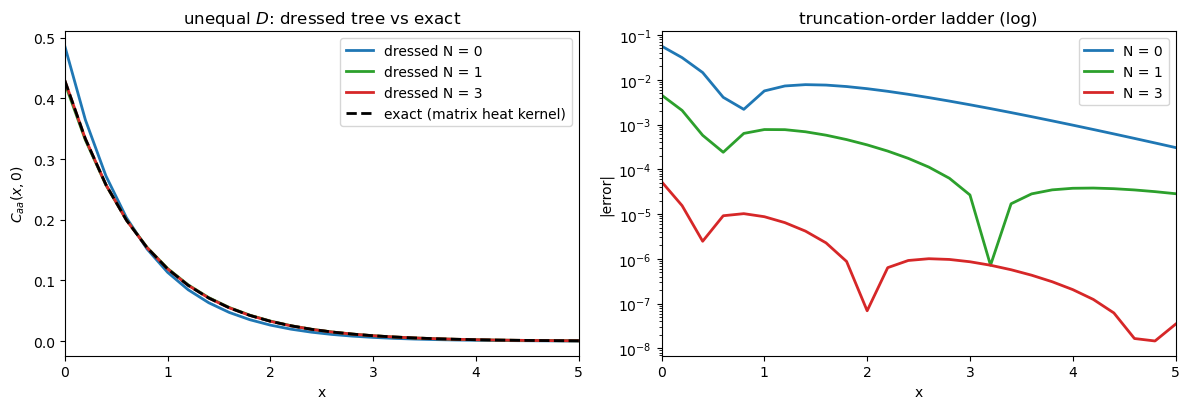

In [6]:
Da, Db, Lbox = 0.9, 0.5, 20.0
xo = np.linspace(0.0, 5.0, 26)

# EXACT oracle on the SAME mode set the dressed theory sums (|n| <= 600):
# the equal-time variance is UV-sensitive (sum ~ 1/q^2 over modes), so theory
# and oracle must truncate identically for the truncation-order ladder to be
# visible down to its true floor.
from scipy.linalg import solve_continuous_lyapunov as _lyap
qs_o = 2.0 * np.pi * np.arange(-600, 601) / Lbox
Cq_o = np.empty(qs_o.size)
for iq, q in enumerate(qs_o):
    A = Mmat + np.diag([Da, Db]) * q * q
    Cq_o[iq] = _lyap(A, Nnoise)[0, 0]
C_or = np.array([(Cq_o * np.cos(qs_o * x)).sum() / Lbox for x in xo])

dressed = {}
for N in (0, 1, 3):
    t0 = time.time()
    out = compute_cumulants(coupled_rd(Da, Db, ga_=0.0, gb_=0.0, dyson=N,
                                       periodic_L=Lbox),
                            fundamental=fund(Da, Db, 0.0, 0.0),
                            external_fields=LEGS['aa'], k=2, max_ell=0,
                            spatial_grid=xo, tau_max=0.0, tau_step=1.0,
                            verbose=False, use_cache=False, parallel=False,
                            mf_dae_n_starts=4)
    dressed[N] = np.asarray(out['C_tau_x'])[0].real
    print('dyson order %d: C_aa(0,0) = %.5f   max|err vs exact| = %.2e   (%.0fs)'
          % (N, dressed[N][0], np.max(np.abs(dressed[N] - C_or)), time.time() - t0))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
cols = {0: 'C0', 1: 'C2', 3: 'C3'}
for N, C in dressed.items():
    ax[0].plot(xo, C, '-', lw=2, color=cols[N], label='dressed N = %d' % N)
    ax[1].semilogy(xo, np.abs(C - C_or) + 1e-16, '-', lw=2, color=cols[N],
                   label='N = %d' % N)
ax[0].plot(xo, C_or, 'k--', lw=2, label='exact (matrix heat kernel)')
ax[0].set_xlim(0, 5); ax[0].set_xlabel('x'); ax[0].set_ylabel(r'$C_{aa}(x, 0)$')
ax[0].set_title(r'unequal $D$: dressed tree vs exact'); ax[0].legend()
ax[1].set_xlim(0, 5); ax[1].set_xlabel('x'); ax[1].set_ylabel('|error|')
ax[1].set_title('truncation-order ladder (log)'); ax[1].legend()
plt.tight_layout(); plt.show()

## Summary

- The **coupled tree** (matrix Lyapunov, analytic spectral IFT) and the **1-loop spectral-assignment** corrections track the simulation for both $C_{aa}$ and the genuinely $\tau$-asymmetric $C_{ab}$; the stabilizing cubics pull the tree-level variance down toward the simulation.
- The **Dyson-dressed** unequal-$D$ tree converges to the exact matrix-heat-kernel answer order by order ($\sim (\|\hat{\mathcal{D}}\|/D_0)^{N+1}$).
- Gated (clean errors, see `docs/dyson_duhamel_integration_plan.md`): unequal-$D$ **loops** beyond order 1, coupled **derivative vertices**, coupled loops on **periodic** boundaries.